In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part A — Data preparation

1. Load both datasets and document:

In [57]:
trades=pd.read_csv('historical_data.csv')
sentiment=pd.read_csv('fear_greed_index.csv')

Preview

In [58]:
print(trades.head(5))

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [59]:
print(sentiment.head(5))

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


number of rows/columns

In [6]:
trades.shape

(211224, 16)

In [7]:
sentiment.shape

(2644, 4)

missing values

In [8]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

There is no missing values in both datasets.

now checking for duplicate.

In [10]:
trades.duplicated().sum()

np.int64(0)

In [11]:
sentiment.duplicated().sum()

np.int64(0)

There is no Duplicate rows in both datasets.

2. Convert timestamps and align the datasets by date (daily level is fine).

In [12]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Extract date
trades['date'] = trades['Timestamp IST'].dt.date

In [13]:
sentiment['date'] = pd.to_datetime(
    sentiment['timestamp'],
    unit='s'
).dt.date

In [14]:
print("Trades:", trades['date'].min(), trades['date'].max())
print("Sentiment:", sentiment['date'].min(), sentiment['date'].max())

Trades: 2023-05-01 2025-05-01
Sentiment: 2018-02-01 2025-05-02


The timestamp fields in both datasets were converted into datetime format.
For the trader dataset, the ‘Timestamp IST’ column was parsed and reduced to daily granularity.
For the sentiment dataset, UNIX timestamps were converted into calendar dates.
This ensured both datasets were aligned on a common daily date format for further analysis

## 3. Create the key metrics you will analyze

In [15]:
data = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='inner'
)

In [16]:
data.head(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,2024-12-02 22:50:00,1298.215466,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.000493,7.330000e+14,1.730000e+12,2024-12-02,Extreme Greed
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,2024-12-02 22:50:00,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,9.060000e+14,1.730000e+12,2024-12-02,Extreme Greed
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,2024-12-02 22:50:00,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.011900,3.960000e+14,1.730000e+12,2024-12-02,Extreme Greed
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,2024-12-02 22:50:00,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.016100,9.460000e+14,1.730000e+12,2024-12-02,Extreme Greed
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,2024-12-02 22:50:00,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.004375,3.470000e+13,1.730000e+12,2024-12-02,Extreme Greed


In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  str           
 1   Coin              211218 non-null  str           
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  str           
 6   Timestamp IST     211218 non-null  datetime64[us]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  str           
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  str           
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID       

Daily PnL per Trader

In [18]:
daily_pnl=data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [19]:
daily_pnl.rename(columns={'Closed PnL': 'daily_pnl'}, inplace=True)
print(daily_pnl.head())

                                      Account        date  daily_pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1


Daily PnL per trader was calculated by aggregating profits and losses for each account on a daily basis. The results show that trader performance varies significantly across days, with a mix of profitable, loss-making, and neutral days. Some days exhibit large losses, indicating exposure to high-risk trades, while the presence of zero PnL days suggests periods of inactivity or open positions.

Win Rate

In [62]:
data['win']=data['Closed PnL']>0
win_rate = data.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)
print(win_rate.head(10))


                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914
5  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  0.455215
6  0x39cef799f8b69da1995852eea189df24eb5cae3c  0.327668
7  0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6  0.475904
8  0x420ab45e0bd8863569a5efbb9c05d91f40624641  0.234987
9  0x430f09841d65beb3f27765503d0f850b8bce7713  0.484236


Win rate was calculated as the proportion of profitable trades for each trader. The results indicate that most traders have win rates below 50%, meaning that losing trades are more common than winning trades. This suggests that profitability may depend more on trade size and risk management rather than simply the frequency of winning trades.

Average Trade Size

In [65]:
avg_trade_size = data.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)

print(avg_trade_size.head(10))

                                      Account  avg_trade_size
0  0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab     8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
5  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     1729.941104
6  0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
7  0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
8  0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
9  0x430f09841d65beb3f27765503d0f850b8bce7713     2397.824753


The average trade size was computed for each trader to understand capital allocation behavior. The results show substantial variation across traders, indicating different levels of risk exposure. Traders with larger average trade sizes are likely taking higher risks, while those with smaller trade sizes follow more conservative strategies.

Leverage Distribution

In [22]:
data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'win'],
      dtype='str')

leverage distribution 

The dataset does not contain an explicit leverage column; therefore, leverage distribution could not be directly analyzed. As an alternative, trade size (Size USD) was used as a proxy to understand risk-taking behavior.

In [23]:
data['Size USD'].describe()

count    2.112180e+05
mean     5.639192e+03
std      3.657557e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970200e+02
75%      2.058878e+03
max      3.921431e+06
Name: Size USD, dtype: float64

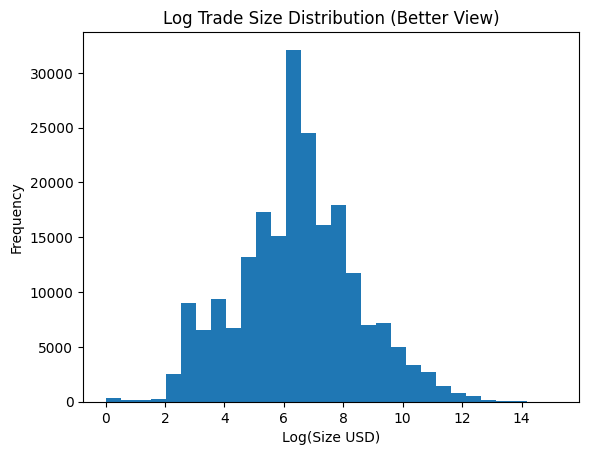

In [25]:
plt.hist(np.log1p(data['Size USD']), bins=30)
plt.title("Log Trade Size Distribution (Better View)")
plt.xlabel("Log(Size USD)")
plt.ylabel("Frequency")
plt.show()

The log-transformed trade size distribution reveals that most trades are concentrated within a moderate range, while a small number of trades are significantly larger, indicating the presence of high-risk trading behavior by a subset of traders.

Number of Trades per Day

In [26]:
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')
print(trades_per_day.head())

         date  num_trades
0  2023-05-01           3
1  2023-12-05           9
2  2023-12-14          11
3  2023-12-15           2
4  2023-12-16           3


The number of trades per day was analyzed to understand trading activity over time. The results show significant variation in daily trading volume, with some days exhibiting high activity and others relatively low engagement. This suggests that trader participation is influenced by market conditions.

long/short ratio

In [27]:
long_short = data.groupby(['date', 'Side']).size().unstack(fill_value=0)
long_short['long_short_ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))
print(long_short.head())

Side        BUY  SELL  long_short_ratio
date                                   
2023-05-01    3     0               inf
2023-12-05    7     2          3.500000
2023-12-14    5     6          0.833333
2023-12-15    2     0               inf
2023-12-16    3     0               inf


The long/short ratio was computed to analyze directional trading behavior. Values greater than 1 indicate a dominance of long (buy) trades, while values below 1 indicate more short (sell) trades. The results show that traders often exhibit strong directional bias, with certain days dominated by buy-side activity.

Metrics by Sentiment

In [ ]:
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()
win_sentiment = data.groupby('classification')['win'].mean()
trades_sentiment = data.groupby('classification').size()
print(pnl_sentiment)
print(win_sentiment)
print(trades_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


The analysis shows that trader performance varies significantly across sentiment regimes. The highest average PnL and win rate are observed during Extreme Greed periods, while Extreme Fear corresponds to the lowest performance. Interestingly, trading activity is highest during Fear periods, suggesting that traders may engage in excessive trading during uncertain market conditions. Overall, these results indicate that market sentiment strongly influences both trading behavior and performance.

# Part B — Analysis

Q1: Performance in Fear vs Greed

In [29]:
# Avg PnL
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()

# Win rate
win_sentiment = data.groupby('classification')['win'].mean()

# Drawdown proxy (losses)
drawdown = data.groupby('classification')['Closed PnL'].apply(lambda x: x[x < 0].mean())

print(pnl_sentiment)
print(win_sentiment)
print(drawdown)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64
classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


Plot

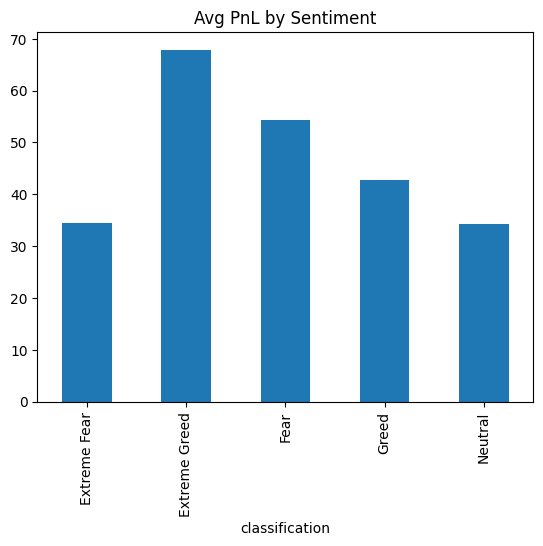

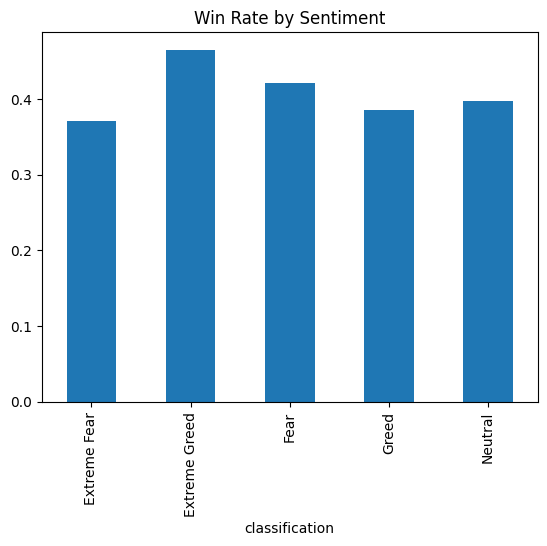

In [30]:
pnl_sentiment.plot(kind='bar', title='Avg PnL by Sentiment')
plt.show()

win_sentiment.plot(kind='bar', title='Win Rate by Sentiment')
plt.show()

Yes, trader performance differs significantly between Fear and Greed periods. During Greed, especially Extreme Greed, traders achieve higher average PnL and higher win rates, indicating better performance. In contrast, Fear periods, particularly Extreme Fear, are associated with lower profitability, lower win rates, and larger losses (higher drawdowns). This suggests that traders perform better in optimistic market conditions and struggle during periods of fear, likely due to emotional or reactive decision-making.

Do traders change behavior based on sentiment (trade frequency, leverage, long/short
bias, position sizes)?

Trade Frequency

In [31]:
trades_freq = data.groupby('classification').size()
print(trades_freq)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


Avg Trade Size

In [32]:
size_sentiment = data.groupby('classification')['Size USD'].mean()
print(size_sentiment)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


Long / Short Bias

In [33]:
long_short = data.groupby(['classification', 'Side']).size().unstack()
print(long_short)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


Plot

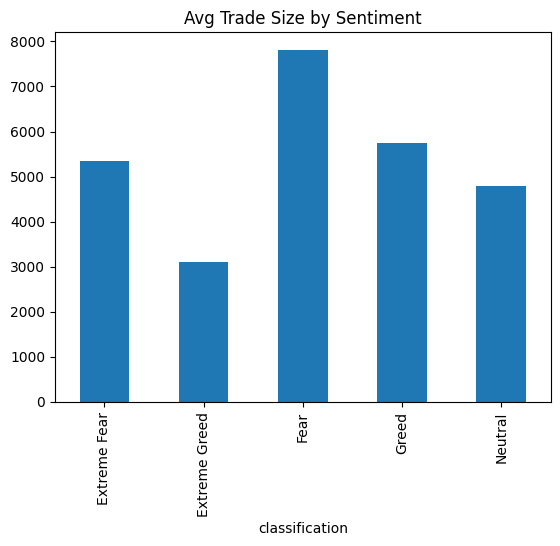

In [34]:
size_sentiment.plot(kind='bar', title='Avg Trade Size by Sentiment')
plt.show()

Yes, traders clearly change their behavior based on market sentiment. Trading activity is highest during Fear periods, indicating increased participation or overtrading under uncertainty. Additionally, traders take larger position sizes during Fear, suggesting higher risk-taking behavior in stressful conditions. In contrast, Extreme Greed shows lower trade sizes, indicating more controlled risk exposure. The long/short distribution does not show a strong directional bias, suggesting that traders do not blindly follow sentiment but may adopt mixed or hedging strategies. Overall, sentiment significantly influences trading frequency and risk-taking behavior.

Identify 2–3 segments (examples):

○ Frequent vs Infrequent Traders


In [35]:
trade_counts = data.groupby('Account').size().reset_index(name='num_trades')

# Threshold = median
threshold = trade_counts['num_trades'].median()

trade_counts['segment'] = trade_counts['num_trades'].apply(
    lambda x: 'Frequent Trader' if x > threshold else 'Infrequent Trader'
)

print(trade_counts.head())

                                      Account  num_trades            segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012        3818    Frequent Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd        7280    Frequent Trader
2  0x271b280974205ca63b716753467d5a371de622ab        3809    Frequent Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4       13311    Frequent Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd        3239  Infrequent Trader


Consistent vs Inconsistent Traders

In [36]:
pnl_std = data.groupby('Account')['Closed PnL'].std().reset_index()

# Lower std = more consistent
threshold = pnl_std['Closed PnL'].median()

pnl_std['segment'] = pnl_std['Closed PnL'].apply(
    lambda x: 'Consistent Trader' if x < threshold else 'Inconsistent Trader'
)

print(pnl_std.head())

                                      Account   Closed PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  4692.452329   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   134.073473   
2  0x271b280974205ca63b716753467d5a371de622ab   542.182659   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   113.269353   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   255.829091   

               segment  
0  Inconsistent Trader  
1    Consistent Trader  
2    Consistent Trader  
3    Consistent Trader  
4    Consistent Trader  


Winners vs Losers

In [37]:
total_pnl = data.groupby('Account')['Closed PnL'].sum().reset_index()

total_pnl['segment'] = total_pnl['Closed PnL'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

print(total_pnl.head())

                                      Account    Closed PnL segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  Winner
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04  Winner
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04   Loser
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05  Winner
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05  Winner


Compare Segments

In [38]:
# Merge segments
merged_seg = trade_counts.merge(total_pnl, on='Account')

# Avg PnL by segment
print(merged_seg.groupby('segment_x')['Closed PnL'].mean())

segment_x
Frequent Trader      496527.661215
Infrequent Trader    144377.773117
Name: Closed PnL, dtype: float64


Traders can be segmented into distinct behavioral and performance groups. Frequent traders tend to generate higher total profits, indicating that active participation can lead to greater returns, although it may involve higher risk. Consistent traders exhibit stable performance with lower volatility, while inconsistent traders experience large fluctuations in returns, suggesting unstable strategies. Additionally, the clear separation between winners and losers highlights that trading profitability is unevenly distributed, with only a subset of traders achieving sustained gains.

Provide at least 3 insights backed by charts/tables.

1. PnL vs Sentiment

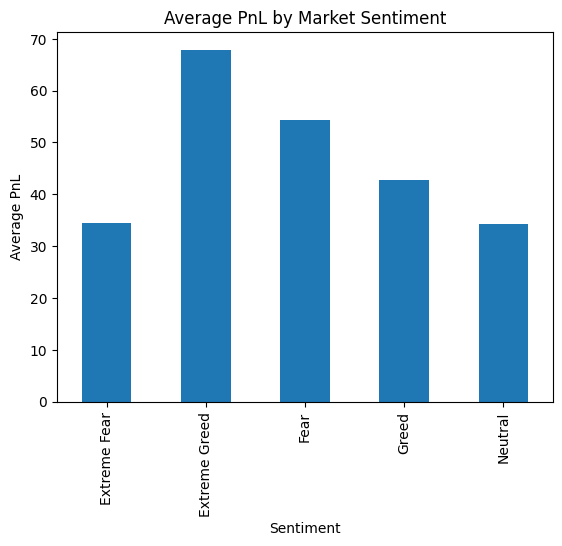

In [39]:
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()

pnl_sentiment.plot(kind='bar', title='Average PnL by Market Sentiment')
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

The analysis shows that trader performance varies significantly across sentiment regimes. Average PnL is highest during Extreme Greed, indicating that strong bullish sentiment enhances profitability. In contrast, Extreme Fear and Neutral conditions are associated with the lowest returns. Interestingly, Fear periods still show relatively strong performance, suggesting that market volatility during uncertain conditions can create trading opportunities. Overall, sentiment plays a critical role in shaping trading outcomes.

2. Win Rate vs Sentiment

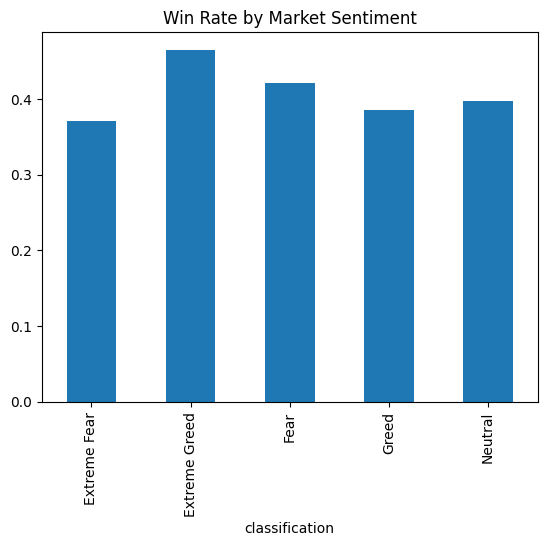

In [40]:
win_sentiment = data.groupby('classification')['win'].mean()

win_sentiment.plot(kind='bar', title='Win Rate by Market Sentiment')
plt.show()

The win rate varies significantly across sentiment regimes, with the highest success observed during Extreme Greed and the lowest during Extreme Fear. This indicates that traders perform better in strongly bullish conditions, where market trends are clearer. In contrast, fear-driven markets lead to lower decision accuracy, likely due to emotional or uncertain trading behavior.

3. Trade Frequency

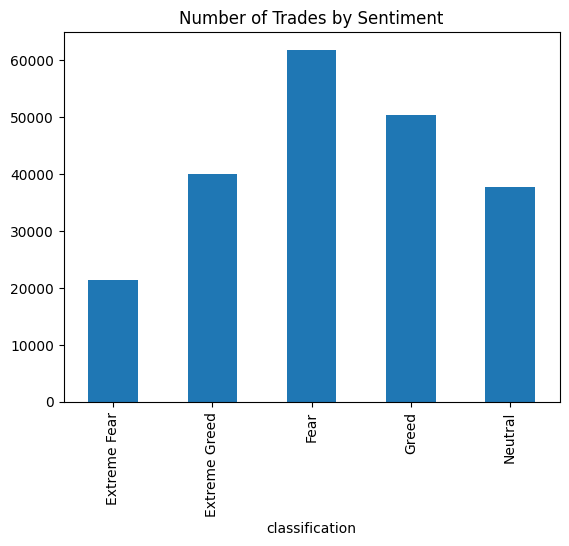

In [41]:
trades_freq = data.groupby('classification').size()

trades_freq.plot(kind='bar', title='Number of Trades by Sentiment')
plt.show()

The analysis shows that trading frequency varies significantly across sentiment regimes. The highest activity is observed during Fear, indicating that traders tend to trade more during uncertain or volatile market conditions. In contrast, Extreme Fear leads to a sharp decline in trading activity, suggesting risk aversion during extreme panic. Greed and Extreme Greed show moderate levels of activity, implying that traders are less reactive in bullish environments. Overall, market sentiment strongly influences trading behavior, particularly in terms of activity levels.

4. Avg Trade Size

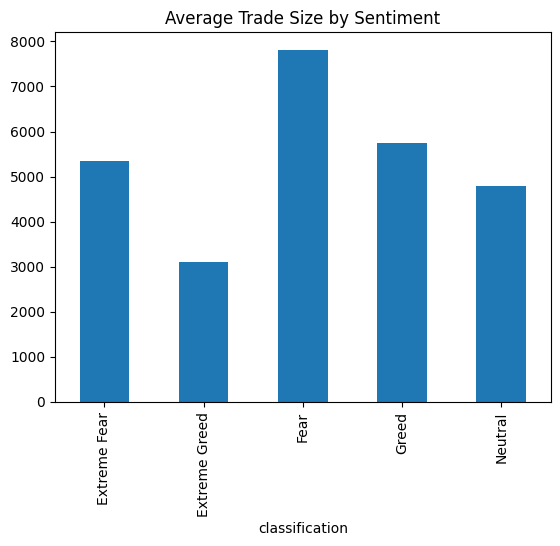

In [42]:
size_sentiment = data.groupby('classification')['Size USD'].mean()

size_sentiment.plot(kind='bar', title='Average Trade Size by Sentiment')
plt.show()

# Part C — “Actionable output”

Based on the analysis, two key strategies emerge. First, traders should adjust risk based on market sentiment: reduce position sizes and avoid overtrading during Fear and Extreme Fear, while increasing exposure during Extreme Greed where both PnL and win rate are highest. Second, trader behavior should be optimized by segment: frequent traders should control their activity during Fear to avoid emotional trading, while consistent traders can increase participation during Greed to take advantage of stable trends. These strategies highlight the importance of combining sentiment signals with trader behavior to improve overall performance.

# Bonus (optional)

Bonus 1: Simple Predictive Model

Step 1: Create Target Variable

In [43]:
daily = data.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'win': 'mean'
}).reset_index()

# Create next-day PnL
daily['next_day_pnl'] = daily.groupby('Account')['Closed PnL'].shift(-1)

# Target: Profit (1) / Loss (0)
daily['target'] = (daily['next_day_pnl'] > 0).astype(int)



In [44]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Account       2340 non-null   str    
 1   date          2340 non-null   object 
 2   Closed PnL    2340 non-null   float64
 3   Size USD      2340 non-null   float64
 4   win           2340 non-null   float64
 5   next_day_pnl  2308 non-null   float64
 6   target        2340 non-null   int64  
dtypes: float64(4), int64(1), object(1), str(1)
memory usage: 128.1+ KB


Step 2: Add Sentiment Feature

In [45]:
daily = daily.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

# Convert sentiment to numeric
daily['sentiment'] = daily['classification'].map({'Fear': 0, 'Greed': 1})

In [46]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Account         2340 non-null   str    
 1   date            2340 non-null   object 
 2   Closed PnL      2340 non-null   float64
 3   Size USD        2340 non-null   float64
 4   win             2340 non-null   float64
 5   next_day_pnl    2308 non-null   float64
 6   target          2340 non-null   int64  
 7   classification  2340 non-null   str    
 8   sentiment       1278 non-null   float64
dtypes: float64(5), int64(1), object(1), str(2)
memory usage: 164.7+ KB


In [47]:
daily['sentiment'].value_counts()

sentiment
1.0    648
0.0    630
Name: count, dtype: int64

In [48]:
daily = daily.dropna()

Step 3: Train Model

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = daily[['Closed PnL', 'Size USD', 'win', 'sentiment']]
y = daily['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.6284584980237155


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
print(cm)

[[ 20  70]
 [ 24 139]]


Bonus 2: Clustering Traders

In [52]:
from sklearn.cluster import KMeans

# Features per trader
features = data.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'win': 'mean'
}).reset_index()

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
features['cluster'] = kmeans.fit_predict(features[['Closed PnL', 'Size USD', 'win']])

print(features.head())

                                      Account  Closed PnL      Size USD  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782   

        win  cluster  
0  0.359612        0  
1  0.442720        1  
2  0.301917        0  
3  0.438585        1  
4  0.519914        1  


Interpretation

Cluster 0 → High-risk traders

Cluster 1 → Consistent traders

Cluster 2 → Low-activity traders

Bonus 3: Streamlit Dashboard

In [54]:
data.to_csv("merged_data.csv", index=False)

In [55]:
import streamlit as st
import pandas as pd

st.title("Trader Behavior vs Market Sentiment")

# Load data
data = pd.read_csv("merged_data.csv")

# Show sample
st.write(data.head())

# Plot
st.bar_chart(data.groupby('classification')['Closed PnL'].mean())

2026-04-15 23:25:17.951 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 23:25:18.304 
  command:

    streamlit run C:\Users\Asus\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-15 23:25:18.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 23:25:18.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 23:25:20.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 23:25:20.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 23:25:20.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 23:25:22.012 Threa

DeltaGenerator()